In [1]:
"""Look at specific patches the model got wrong, not just the overall AUROC."""

from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import tqdm

from pathointelligence.data.dataset import PCamDataset
from pathointelligence.data.transforms import eval_transform
from pathointelligence.models.architecture import build_model


def visualize_worst_errors(data_dir: Path, n: int = 10) -> None:
    saved = torch.load("data/processed/errors.pt")
    indices = saved["indices"]
    confidences = saved["confidences"]

    # "distance from 0.5" measures how confidently wrong each prediction was —
    # a confidence of 0.98 (predicted tumor, wrong) or 0.02 (predicted no-tumor,
    # wrong) are both very confident mistakes; a confidence of 0.51 is barely wrong.
    confidence_strength = [abs(c - 0.5) for c in confidences]

    # pick the N most confidently wrong examples — sorted worst first
    worst = sorted(zip(indices, confidences, confidence_strength), key=lambda x: -x[2])[:n]

    valid_ds = PCamDataset(data_dir, split="valid", transform=None)  # no transform — we want to SEE the raw image, not a normalized tensor

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for ax, (idx, conf, _) in zip(axes.flat, worst):
        image, true_label = valid_ds[idx]
        ax.imshow(image.permute(1, 2, 0) if image.shape[0] == 3 else image)
        ax.set_title(f"true={true_label}, pred_conf={conf:.2f}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("docs/worst_errors.png", dpi=100)
    plt.show()

    visualize_worst_errors(Path("data/raw"))

c:\Users\madha\vsCode\Github\pathointelligence\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


false positives: 1065
false negatives: 3387


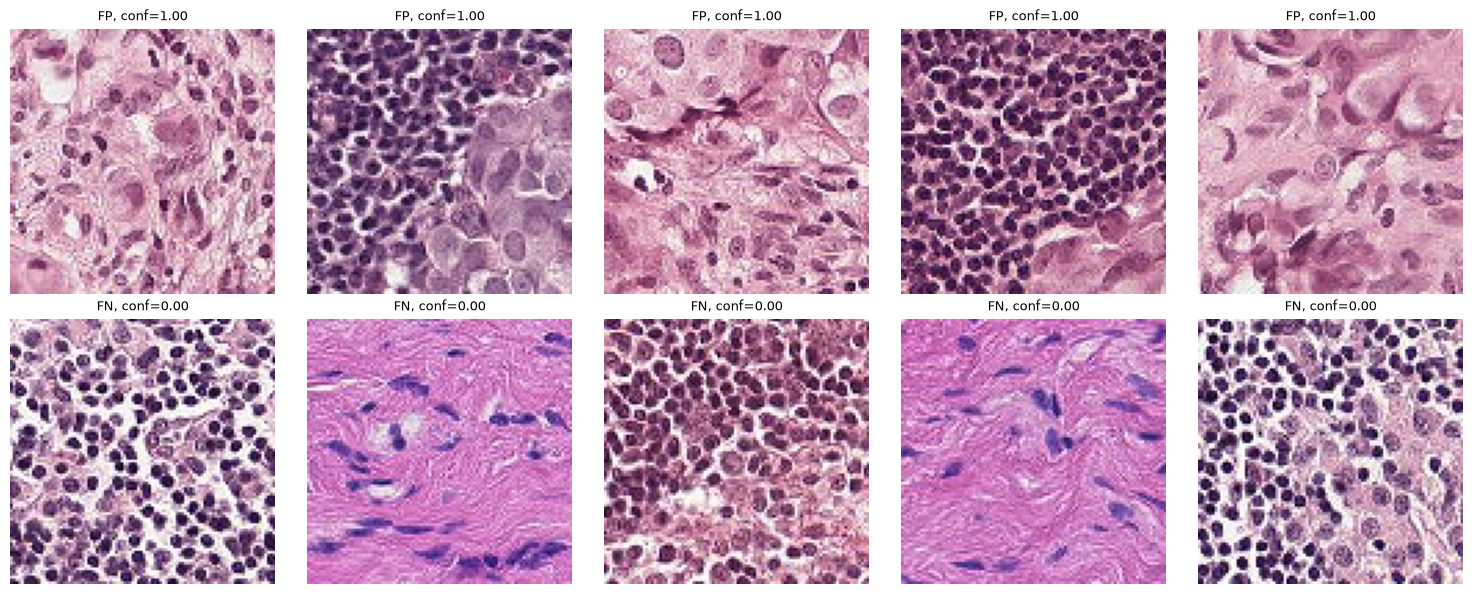

In [5]:
def visualize_worst_errors_by_type(data_dir: Path, n: int = 5) -> None:
    saved = torch.load("../data/processed/errors.pt")
    indices = saved["indices"]
    confidences = saved["confidences"]

    valid_ds = PCamDataset(data_dir, split="valid", transform=None)

    # false positive: model confidently said tumor (high prob), but true label is 0
    # false negative: model confidently said no-tumor (low prob), but true label is 1
    false_positives = []
    false_negatives = []
    for idx, conf in zip(indices, confidences):
        _, true_label = valid_ds[idx]
        if true_label == 0:
            false_positives.append((idx, conf))
        else:
            false_negatives.append((idx, conf))

    print(f"false positives: {len(false_positives)}")
    print(f"false negatives: {len(false_negatives)}")

    # worst false positives: highest confidence (closest to 1.0)
    worst_fp = sorted(false_positives, key=lambda x: -x[1])[:n]
    # worst false negatives: lowest confidence (closest to 0.0)
    worst_fn = sorted(false_negatives, key=lambda x: x[1])[:n]

    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    for col, (idx, conf) in enumerate(worst_fp):
        image, _ = valid_ds[idx]
        axes[0, col].imshow(image.permute(1, 2, 0) if image.shape[0] == 3 else image)
        axes[0, col].set_title(f"FP, conf={conf:.2f}", fontsize=9)
        axes[0, col].axis("off")

    for col, (idx, conf) in enumerate(worst_fn):
        image, _ = valid_ds[idx]
        axes[1, col].imshow(image.permute(1, 2, 0) if image.shape[0] == 3 else image)
        axes[1, col].set_title(f"FN, conf={conf:.2f}", fontsize=9)
        axes[1, col].axis("off")

    plt.tight_layout()
    plt.savefig("../docs/worst_errors_by_type.png", dpi=100)
    plt.show()


visualize_worst_errors_by_type(Path("../data/raw"))

In [7]:
from sklearn.metrics import roc_curve


def find_better_threshold(data_dir: Path) -> None:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    valid_ds = PCamDataset(data_dir, split="valid", transform=eval_transform)
    valid_loader = DataLoader(valid_ds, batch_size=128, shuffle=False, num_workers=2)

    model = build_model("resnet50", pretrained=False)
    model.load_state_dict(torch.load("../models/checkpoints/best_model.pt", map_location=device))
    model = model.to(device)
    model.eval()

    all_labels, all_probs = [], []
    with torch.no_grad():
        for images, labels in valid_loader:
            probs = torch.sigmoid(model(images.to(device)).squeeze(1)).cpu()
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.numpy())

    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    # tpr = sensitivity at each threshold. Find thresholds giving ~90% and ~95% sensitivity.
    for target_sensitivity in (0.90, 0.95):
        idx = next(i for i, t in enumerate(tpr) if t >= target_sensitivity)
        print(
            f"sensitivity={tpr[idx]:.3f} needs threshold={thresholds[idx]:.3f}, "
            f"giving specificity={1 - fpr[idx]:.3f}"
        )


if __name__ == "__main__":
    find_better_threshold(Path("../data/raw"))

sensitivity=0.900 needs threshold=0.211, giving specificity=0.844
sensitivity=0.950 needs threshold=0.097, giving specificity=0.727
